In [5]:
# LOAD DATA
# ==========================================================
from google.colab import files
import pandas as pd
import io

# Step 1 — Upload (a button appears, click it and select your CSV)
uploaded = files.upload()

# Step 2 — Store in a variable
# 'uploaded' is a dict: { "filename.csv": <bytes> }
filename = list(uploaded.keys())[0]          # gets the filename automatically
df = pd.read_csv(io.BytesIO(uploaded[filename]))  # reads bytes → DataFrame

# Step 3 — Verify it loaded correctly
print(df.shape)
print(df.head())

Saving synthetic_customer_churn_100k.csv to synthetic_customer_churn_100k (1).csv
(100000, 9)
   CustomerID  Age  Gender  Tenure  MonthlyCharges        Contract  \
0           1   56  Female      68          147.58        Two year   
1           2   69    Male      32           22.54  Month-to-month   
2           3   46  Female      10           52.47        One year   
3           4   32    Male      22          109.67  Month-to-month   
4           5   60  Female      54          130.98  Month-to-month   

      PaymentMethod  TotalCharges Churn  
0     Bank transfer      10052.03    No  
1      Mailed check        686.78    No  
2  Electronic check        537.88    No  
3      Mailed check       2390.04   Yes  
4       Credit card       7081.28    No  



Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  object 
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  object 
 6   PaymentMethod   100000 non-null  object 
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 6.9+ MB
None

Missing Values
CustomerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64

Churn Distribution
Churn
No     66856
Yes    33144
Name: count, dtype: int64


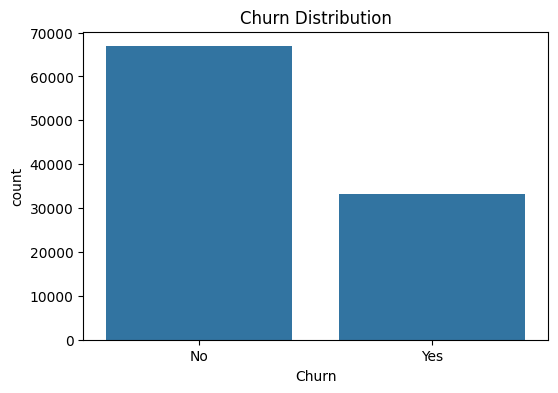

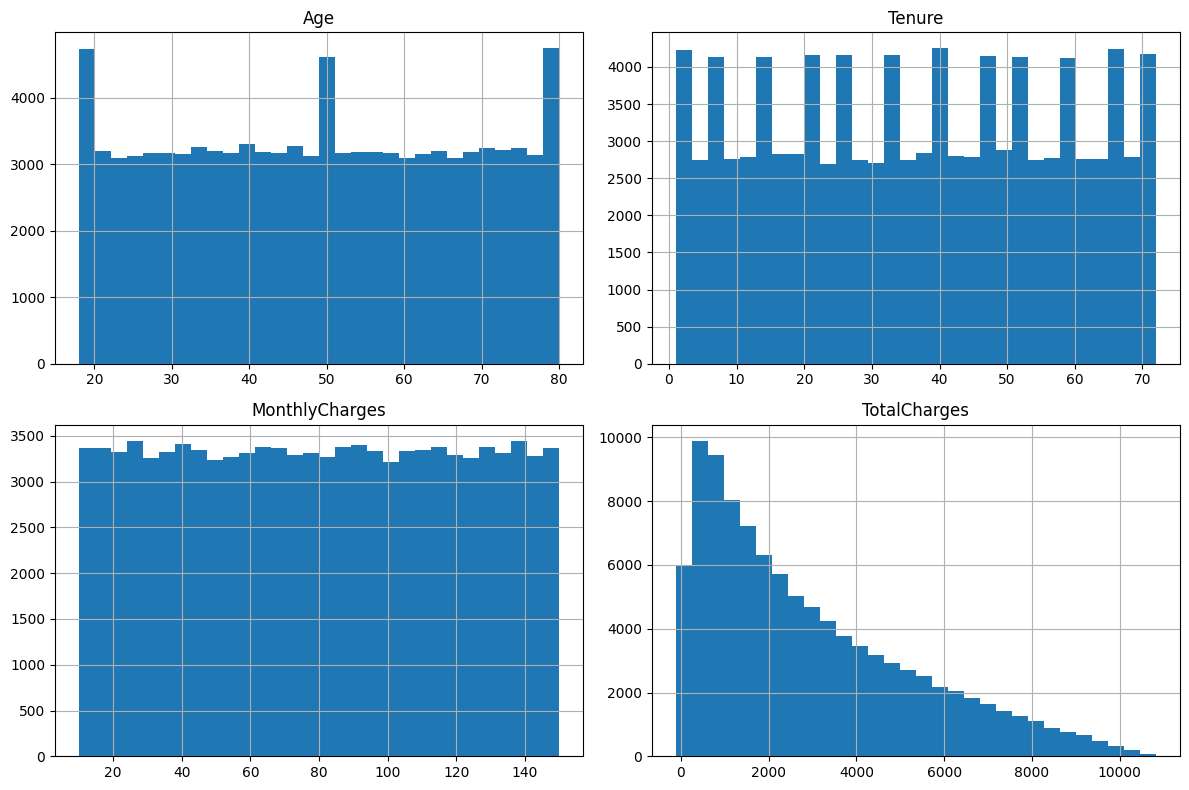

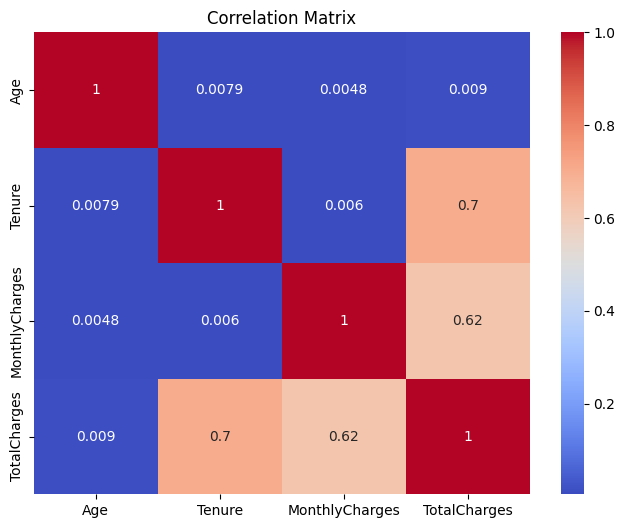

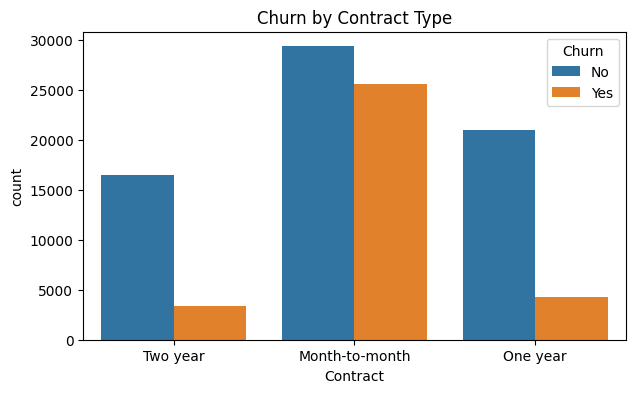


Logistic Regression
              precision    recall  f1-score   support

           0       0.76      0.85      0.80     13371
           1       0.61      0.47      0.53      6629

    accuracy                           0.72     20000
   macro avg       0.69      0.66      0.67     20000
weighted avg       0.71      0.72      0.71     20000



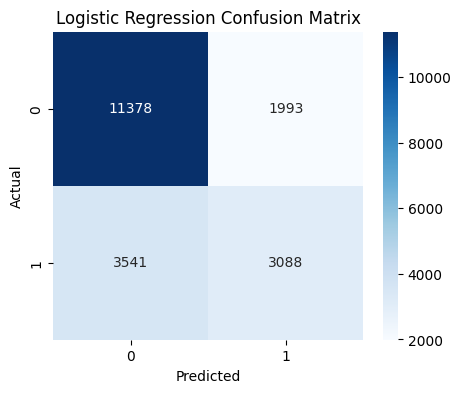


Decision Tree
              precision    recall  f1-score   support

           0       0.79      0.86      0.83     13371
           1       0.67      0.55      0.60      6629

    accuracy                           0.76     20000
   macro avg       0.73      0.71      0.71     20000
weighted avg       0.75      0.76      0.75     20000



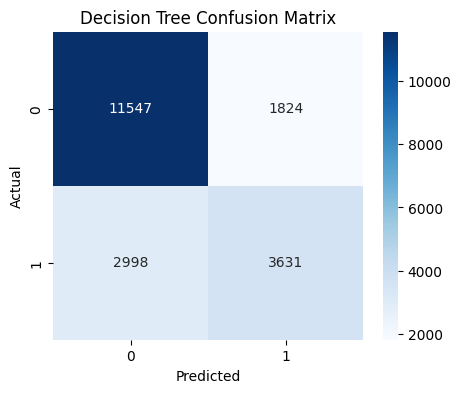


Random Forest
              precision    recall  f1-score   support

           0       0.78      0.84      0.81     13371
           1       0.61      0.51      0.56      6629

    accuracy                           0.73     20000
   macro avg       0.69      0.68      0.68     20000
weighted avg       0.72      0.73      0.72     20000



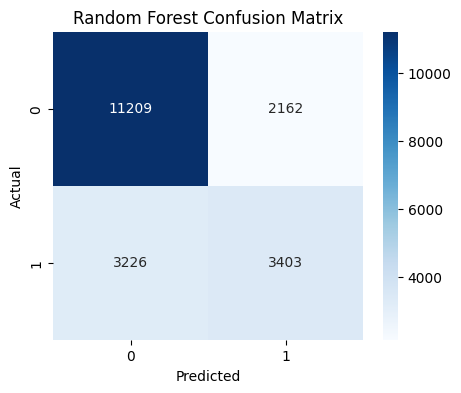


XGBoost
              precision    recall  f1-score   support

           0       0.80      0.86      0.83     13371
           1       0.67      0.56      0.61      6629

    accuracy                           0.76     20000
   macro avg       0.73      0.71      0.72     20000
weighted avg       0.76      0.76      0.76     20000



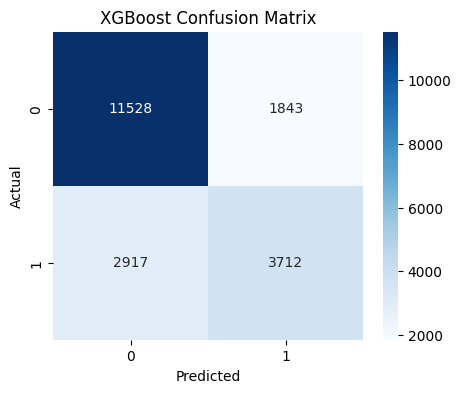


Model Comparison
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
3              XGBoost    0.7620   0.668227  0.559964  0.609324  0.804047
1        Decision Tree    0.7589   0.665628  0.547745  0.600960  0.801827
2        Random Forest    0.7306   0.611500  0.513350  0.558143  0.787650
0  Logistic Regression    0.7233   0.607754  0.465832  0.527412  0.771881


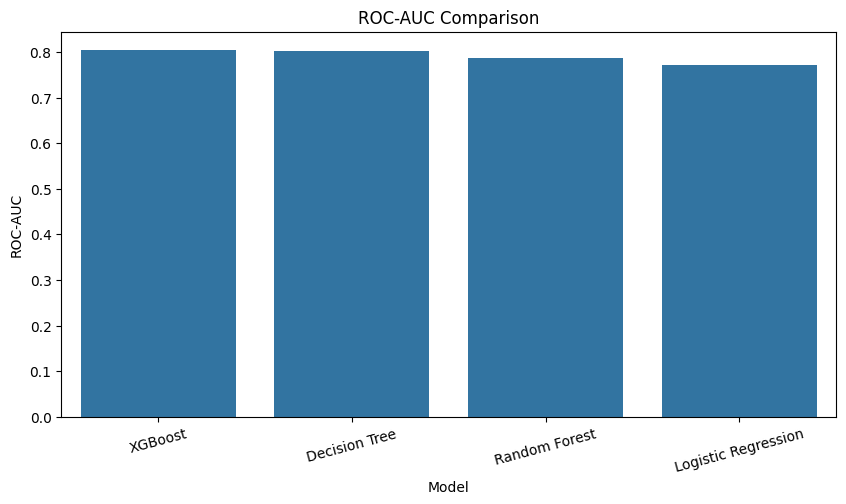

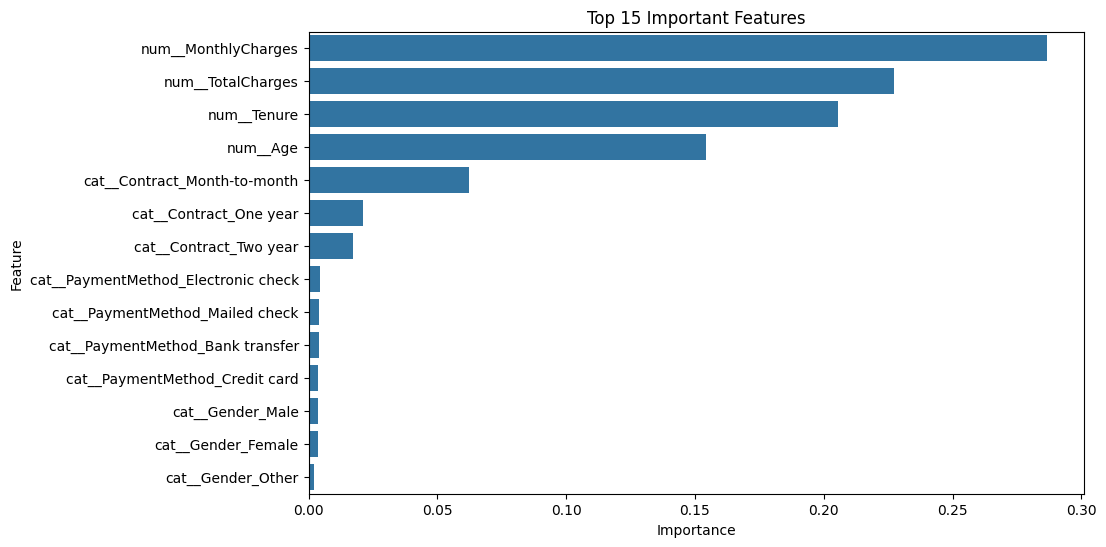


Top Features
                                Feature  Importance
2                   num__MonthlyCharges    0.286509
3                     num__TotalCharges    0.227226
1                           num__Tenure    0.205557
0                              num__Age    0.154157
7          cat__Contract_Month-to-month    0.062383
8                cat__Contract_One year    0.021261
9                cat__Contract_Two year    0.017187
12  cat__PaymentMethod_Electronic check    0.004282
13      cat__PaymentMethod_Mailed check    0.004182
10     cat__PaymentMethod_Bank transfer    0.003919
11       cat__PaymentMethod_Credit card    0.003786
5                      cat__Gender_Male    0.003720
4                    cat__Gender_Female    0.003712
6                     cat__Gender_Other    0.002118


In [6]:

# ==========================================================
# Models:
# 1. Logistic Regression
# 2. Decision Tree
# 3. Random Forest
# 4. XGBoost
# ==========================================================

# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

# ==========================================================
# BASIC EDA
# ==========================================================

print("\nDataset Info")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nChurn Distribution")
print(df["Churn"].value_counts())

# -------------------------
# Target Distribution
# -------------------------

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

# -------------------------
# Numerical Features
# -------------------------

num_cols = [
    "Age",
    "Tenure",
    "MonthlyCharges",
    "TotalCharges"
]

df[num_cols].hist(
    figsize=(12,8),
    bins=30
)

plt.tight_layout()
plt.show()

# -------------------------
# Correlation Heatmap
# -------------------------

plt.figure(figsize=(8,6))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

# -------------------------
# Churn by Contract Type
# -------------------------

plt.figure(figsize=(7,4))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Churn by Contract Type")
plt.show()

# ==========================================================
# DATA PREPROCESSING
# ==========================================================

# Target Encoding

df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

# Remove CustomerID

df.drop("CustomerID", axis=1, inplace=True)

X = df.drop("Churn", axis=1)
y = df["Churn"]

# Identify columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns

# Preprocessing Pipelines

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==========================================================
# MODEL DEFINITIONS
# ==========================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42,
            max_depth=8
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42
        )
}

# ==========================================================
# TRAIN + EVALUATE
# ==========================================================

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline, "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)[:,1]
    else:
        y_prob = y_pred

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

    print("\n" + "="*60)
    print(name)
    print("="*60)

    print(classification_report(
        y_test,
        y_pred
    ))

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

# ==========================================================
# MODEL COMPARISON
# ==========================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

print("\nModel Comparison")
print(results_df)

# ==========================================================
# VISUALIZE COMPARISON
# ==========================================================

plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="ROC-AUC"
)

plt.title("ROC-AUC Comparison")
plt.xticks(rotation=15)

plt.show()

# ==========================================================
# FEATURE IMPORTANCE (RANDOM FOREST)
# ==========================================================

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model",
     RandomForestClassifier(
         n_estimators=200,
         random_state=42
     ))
])

rf_pipeline.fit(X_train, y_train)

feature_names = rf_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = rf_pipeline.named_steps[
    "model"
].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")
plt.show()

print("\nTop Features")
print(importance_df)
